# Phase 3 CHAR — Within-band Bivariate Redundancy

Bivariate Moran's I (global + LISA) for the 11 high-correlation pairs (r > 0.9) from F4.9.
Central question: *where spatially* does the redundancy hold, and where does it break down?

> **Critical distinction** — do not conflate these two groups:
> - **S/U pairs** (same variable, local vs. upstream): divergence is the *substantive signal* — HH/LL = s/u convergence zones; HL/LH = s/u divergence zones (e.g., mountain-fed coastal basins, Ur-like enclosed basins).
> - **Same-band non-S/U pairs**: high concordance expected everywhere; spatial divergence = anomalies relevant to variable selection, not ecological structure.

In [1]:
# Cell 2 — imports and configuration
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from libpysal.weights import Queen
from esda.moran import Moran_BV, Moran_Local_BV
import psycopg
from dotenv import load_dotenv
import os
import pathlib
import time

load_dotenv()
%matplotlib inline

SEED    = 42
N_PERM  = 999
P_SIG   = 0.05
TABLE   = 'basin08'

# Resolve repo root whether kernel runs from repo root or notebook directory
_cwd = pathlib.Path.cwd()
REPO_ROOT = _cwd if (_cwd / 'spatial').exists() else _cwd.parents[2]
PARQ_OUT  = REPO_ROOT / 'output/edop/spatial/bivariate_redundancy.parquet'
MAP_DIR   = REPO_ROOT / 'spatial'
PARQ_OUT.parent.mkdir(parents=True, exist_ok=True)
print(f'REPO_ROOT: {REPO_ROOT}')

QUAD_COLORS = {'HH': '#d7191c', 'LL': '#2c7bb6', 'LH': '#abd9e9', 'HL': '#fdae61', 'NS': '#f0f0f0'}
print('Config loaded.')

Config loaded.


## Pair definitions

Log-transform decisions from skewness check: `ari_ix_sav/uav` (6.86/6.59), `dis_m3_pyr/pmn/pmx` (41/45/34), `ria_ha_usu` (29.36) all need log1p. Temperature columns stored ×10 in DB — divide by 10 before analysis.

In [2]:
# Cell 4 — pair definitions
# NOTE: s/u pairs and same-band non-s/u pairs have structurally different findings.
# S/U divergence = substantive signal. Same-band redundancy = variable-selection bookkeeping.

SU_PAIRS = [
    {'pair_id': 'tmp_su',      'col_x': 'tmp_dc_syr', 'col_y': 'tmp_dc_uyr', 'log_x': False, 'log_y': False, 'div10': True,  'band': 'C', 'label': 'T_yr s×u'},
    {'pair_id': 'pre_su',      'col_x': 'pre_mm_syr', 'col_y': 'pre_mm_uyr', 'log_x': False, 'log_y': False, 'div10': False, 'band': 'C', 'label': 'P_yr s×u'},
    {'pair_id': 'ari_su',      'col_x': 'ari_ix_sav', 'col_y': 'ari_ix_uav', 'log_x': True,  'log_y': True,  'div10': False, 'band': 'C', 'label': 'Ari s×u'},
    {'pair_id': 'hft_su',      'col_x': 'hft_ix_s09', 'col_y': 'hft_ix_u09', 'log_x': False, 'log_y': False, 'div10': False, 'band': 'D', 'label': 'HFT s×u'},
    {'pair_id': 'crp_su',      'col_x': 'crp_pc_sse', 'col_y': 'crp_pc_use', 'log_x': False, 'log_y': False, 'div10': False, 'band': 'D', 'label': 'Crop s×u'},
]

SB_PAIRS = [
    {'pair_id': 'dis_yr_mn',   'col_x': 'dis_m3_pyr', 'col_y': 'dis_m3_pmn', 'log_x': True,  'log_y': True,  'div10': False, 'band': 'B', 'label': 'Dis_yr × Dis_min'},
    {'pair_id': 'dis_yr_mx',   'col_x': 'dis_m3_pyr', 'col_y': 'dis_m3_pmx', 'log_x': True,  'log_y': True,  'div10': False, 'band': 'B', 'label': 'Dis_yr × Dis_max'},
    {'pair_id': 'dis_mx_ria',  'col_x': 'dis_m3_pmx', 'col_y': 'ria_ha_usu', 'log_x': True,  'log_y': True,  'div10': False, 'band': 'B', 'label': 'Dis_max × RiverArea_u'},
    {'pair_id': 'hdi_gdp',     'col_x': 'hdi_ix_sav', 'col_y': 'gdp_ud_sav', 'log_x': False, 'log_y': False, 'div10': False, 'band': 'D', 'label': 'HDI × GDP'},
    {'pair_id': 'tmp_syr_smn', 'col_x': 'tmp_dc_syr', 'col_y': 'tmp_dc_smn', 'log_x': False, 'log_y': False, 'div10': True,  'band': 'C', 'label': 'T_yr × T_min'},
    {'pair_id': 'tmp_smn_uyr', 'col_x': 'tmp_dc_smn', 'col_y': 'tmp_dc_uyr', 'log_x': False, 'log_y': False, 'div10': True,  'band': 'C', 'label': 'T_min × T_yr_u'},
]

ALL_PAIRS = SU_PAIRS + SB_PAIRS
SU_IDS    = {p['pair_id'] for p in SU_PAIRS}

print(f'S/U pairs: {len(SU_PAIRS)}, Same-band non-S/U: {len(SB_PAIRS)}, Total: {len(ALL_PAIRS)}')

S/U pairs: 5, Same-band non-S/U: 6, Total: 11


## Load basin08 at L8

In [3]:
# Cell 6 — load basin08 at L8
def db_connect():
    return psycopg.connect(
        host=os.getenv('PGHOST'), port=os.getenv('PGPORT'),
        dbname=os.getenv('PGDATABASE'), user=os.getenv('PGUSER'),
        password=os.getenv('PGPASSWORD')
    )

ALL_COLS = sorted({p['col_x'] for p in ALL_PAIRS} | {p['col_y'] for p in ALL_PAIRS})
col_list = ', '.join(ALL_COLS)

sql = f'SELECT hybas_id, geom, {col_list} FROM {TABLE} ORDER BY hybas_id'

print('Loading L8 data...')
t0 = time.time()
with db_connect() as conn:
    gdf = gpd.read_postgis(sql, conn, geom_col='geom', index_col='hybas_id')
print(f'Loaded: {len(gdf):,} basins in {time.time()-t0:.1f}s')
print(f'Columns ({len(ALL_COLS)}): {ALL_COLS}')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/geopandas/io/sql.py:467: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(spatial_ref_sys_sql, con)


## Queen contiguity weights at L8

Building from scratch. If `w` is already in kernel memory from a prior run, skip this cell.

In [4]:
# Cell 8 — Queen contiguity weights at L8 (~5 min)
print('Building Queen weights (L8) — expect ~5 min...')
t0 = time.time()
w = Queen.from_dataframe(gdf, use_index=True)
w.transform = 'r'
print(f'Done [{time.time()-t0:.0f}s]: n={w.n:,}, islands={len(w.islands)}, '
      f'mean_neighbors={np.mean(list(w.cardinalities.values())):.2f}')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 716 disconnected components.
 There are 568 islands with ids: 1080034490.0, 1080034560.0, 1080034570.0, 1080034600.0, 1080034610.0, 1080034680.0, 1080034700.0, 1080034760.0, 1080034810.0, 1080034820.0, 1080034830.0, 1080034850.0, 1080034860.0, 1080034900.0, 1080035070.0, 1080035090.0, 1080035120.0, 1080040030.0, 1080040040.0, 1080040050.0, 1080040110.0, 1080040140.0, 1080040160.0, 1080040180.0, 2080045150.0, 2080045590.0, 2080045610.0, 2080045660.0, 2080045750.0, 2080045780.0, 2080045870.0, 2080045930.0, 2080045940.0, 2080046030.0, 2080046070.0, 2080046110.0, 2080046150.0, 2080046220.0, 2080046410.0, 2080046420.0, 2080046430.0, 2080046470.0, 2080047450.0, 2080047460.0, 2080047470.0, 2080048590.0, 2080048620.0, 2080048770.0, 2080053980.0, 2080054000.0, 2080054060.0, 2080054100.0, 2080054110.0, 2080054120.0, 2080054130.0, 2080054140

## Analysis helpers

`preprocess_col` applies sentinel masking, ÷10 (temp), and log1p. `run_bivariate_pair` calls `Moran_BV` (global) and `Moran_Local_BV` (LISA), returning a per-basin classification DataFrame.

In [7]:
# Cell 10 — preprocessing and bivariate runner
def preprocess_col(series, log_transform=False, div10=False):
    s = series.copy().astype(float)
    s = s.replace(-9999, np.nan)
    if div10:
        s = s / 10.0
    if log_transform:
        s = np.log1p(s.clip(lower=0))
    return s

def run_bivariate_pair(gdf, w, pair):
    x_raw = preprocess_col(gdf[pair['col_x']], log_transform=pair['log_x'], div10=pair['div10'])
    y_raw = preprocess_col(gdf[pair['col_y']], log_transform=pair['log_y'], div10=pair['div10'])
    x = x_raw.fillna(x_raw.median()).values
    y = y_raw.fillna(y_raw.median()).values

    np.random.seed(SEED)
    mi = Moran_BV(x, y, w, permutations=N_PERM)
    np.random.seed(SEED)
    li = Moran_Local_BV(x, y, w, transformation='r', permutations=N_PERM)

    sig      = li.p_sim < P_SIG
    quads    = np.where(sig, li.q, 0)
    quad_map = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL', 0: 'NS'}
    lisa_labels = np.array([quad_map[q] for q in quads])

    df = pd.DataFrame({
        'pair_id':    pair['pair_id'],
        'hybas_id':   gdf.index,
        'scale':      'L8',
        'band':       pair['band'],
        'group':      'su' if pair['pair_id'] in SU_IDS else 'sb',
        'lisa_class': lisa_labels,
        'p_value':    li.p_sim,
        'local_I':    li.Is,
        'quad':       quads,
    })
    return mi, li, df

def fmt_row(label, mi, df):
    n = len(df)
    c = df['lisa_class'].value_counts()
    hh, ll, hl, lh, ns = (c.get(k, 0)/n*100 for k in ('HH', 'LL', 'HL', 'LH', 'NS'))
    return f'{label:<28} {mi.I:>8.4f} {mi.p_sim:>8.3f} | {hh:4.1f} {ll:4.1f} {hl:4.1f} {lh:4.1f} {ns:5.1f}'

print('Functions defined.')

Functions defined.


## S/U pairs

For s/u pairs the substantive question is where local and upstream values *diverge*. HL basins = locally drier/cooler/lower than their upstream catchment (e.g., rain-shadow basins, irrigated lowlands). LH basins = locally wetter/warmer/higher than catchment (e.g., orographic pockets, mountain-fed coastal fans).

In [8]:
# Cell 12 — S/U pairs: bivariate global Moran + LISA
results = {}
dfs     = []

print('=== S/U PAIRS (local × upstream — divergence = substantive signal) ===')
print(f'{"Pair":<28} {"I_BV":>8} {"p_sim":>8} | {"HH%":>5} {"LL%":>5} {"HL%":>5} {"LH%":>5} {"NS%":>6}')
print('-' * 70)

for pair in SU_PAIRS:
    mi, li, df = run_bivariate_pair(gdf, w, pair)
    results[pair['pair_id']] = (mi, li, df)
    dfs.append(df)
    print(fmt_row(pair['label'], mi, df))

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/esda/moran.py:1832: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


## Same-band non-S/U pairs

High global r means these pairs are near-redundant everywhere. The LISA question: are there geographic patches where the redundancy breaks down? For discharge pairs, seasonal variability (dis_yr vs dis_min/max) drives divergence in highly seasonal catchments. For HDI×GDP, institutional/distributional breakdowns in historically contested regions.

In [9]:
# Cell 14 — same-band non-S/U pairs
print('=== SAME-BAND NON-S/U PAIRS (variable-selection redundancy) ===')
print(f'{"Pair":<28} {"I_BV":>8} {"p_sim":>8} | {"HH%":>5} {"LL%":>5} {"HL%":>5} {"LH%":>5} {"NS%":>6}')
print('-' * 70)

for pair in SB_PAIRS:
    mi, li, df = run_bivariate_pair(gdf, w, pair)
    results[pair['pair_id']] = (mi, li, df)
    dfs.append(df)
    print(fmt_row(pair['label'], mi, df))

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/esda/moran.py:1832: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


## LISA maps

Colour scheme: HH = red (both values high, local concordance), LL = blue (both low), HL = orange (local high / upstream low or X high / Y low), LH = light blue (local low / upstream high or X low / Y high), NS = grey.

In [15]:
MAP_DIR  = pathlib.Path('/Users/karlg/Documents/repos/_cedop/spatial')
PARQ_OUT = pathlib.Path('/Users/karlg/Documents/repos/_cedop/output/edop/spatial/bivariate_redundancy.parquet')

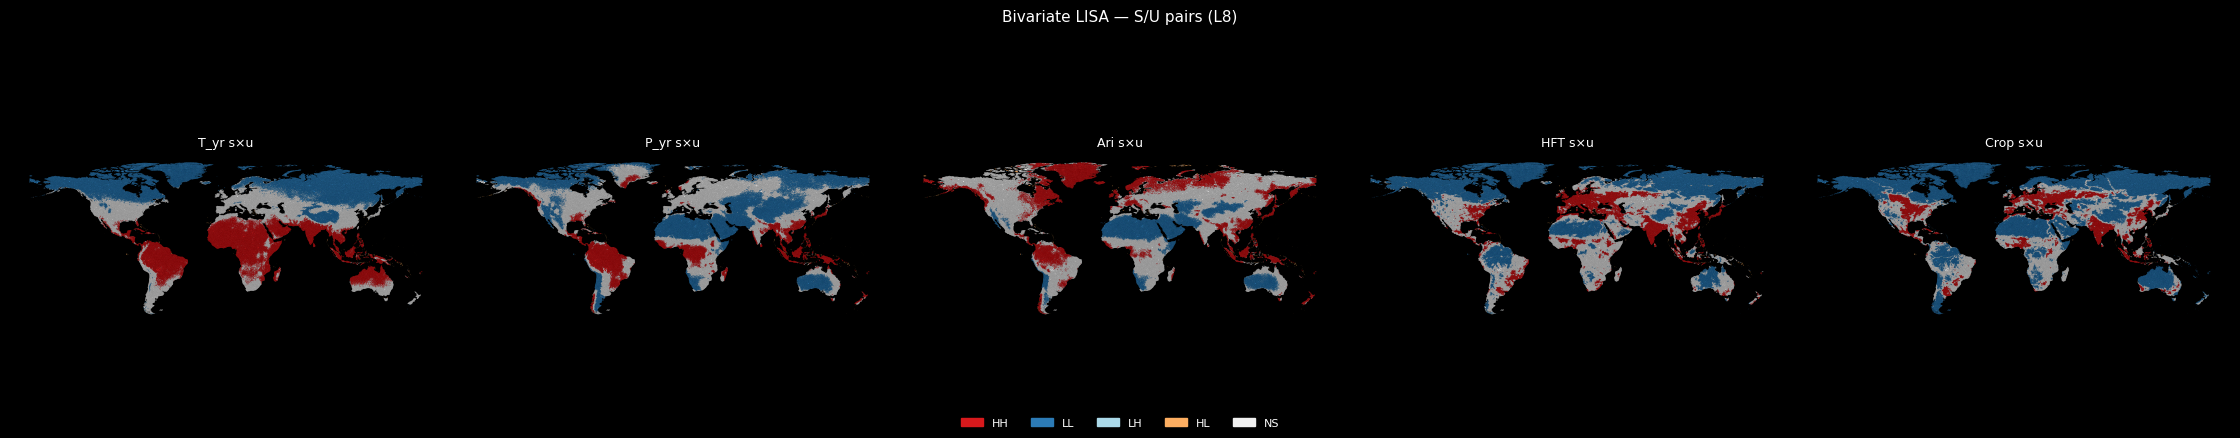

In [16]:
# Cell 16 — LISA maps: S/U pairs (5 panels)
geom_col = gdf.geometry.name

def plot_group_maps(pairs_list, title, out_path):
    ncols = len(pairs_list)
    fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4.2))
    if ncols == 1:
        axes = [axes]
    for ax, pair in zip(axes, pairs_list):
        df    = results[pair['pair_id']][2]
        pgdf  = gdf[[geom_col]].copy()
        pgdf['lisa_class'] = df.set_index('hybas_id')['lisa_class']
        colors = pgdf['lisa_class'].map(QUAD_COLORS).fillna('#f0f0f0')
        pgdf.plot(ax=ax, color=colors.values, linewidth=0, aspect='equal')
        ax.set_title(pair['label'], fontsize=9)
        ax.axis('off')
    patches = [mpatches.Patch(color=v, label=k) for k, v in QUAD_COLORS.items()]
    fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=8, frameon=False)
    fig.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    try:
        fig.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {out_path}')
    except Exception as e:
        import traceback, io
        buf = io.StringIO()
        traceback.print_exc(file=buf)
        open('/tmp/cell16_err.txt','w').write(buf.getvalue())
        print('ERROR written to /tmp/cell16_err.txt')
        traceback.print_exc()

plot_group_maps(SU_PAIRS, 'Bivariate LISA — S/U pairs (L8)', MAP_DIR / '15_bivariate_redundancy_su.png')

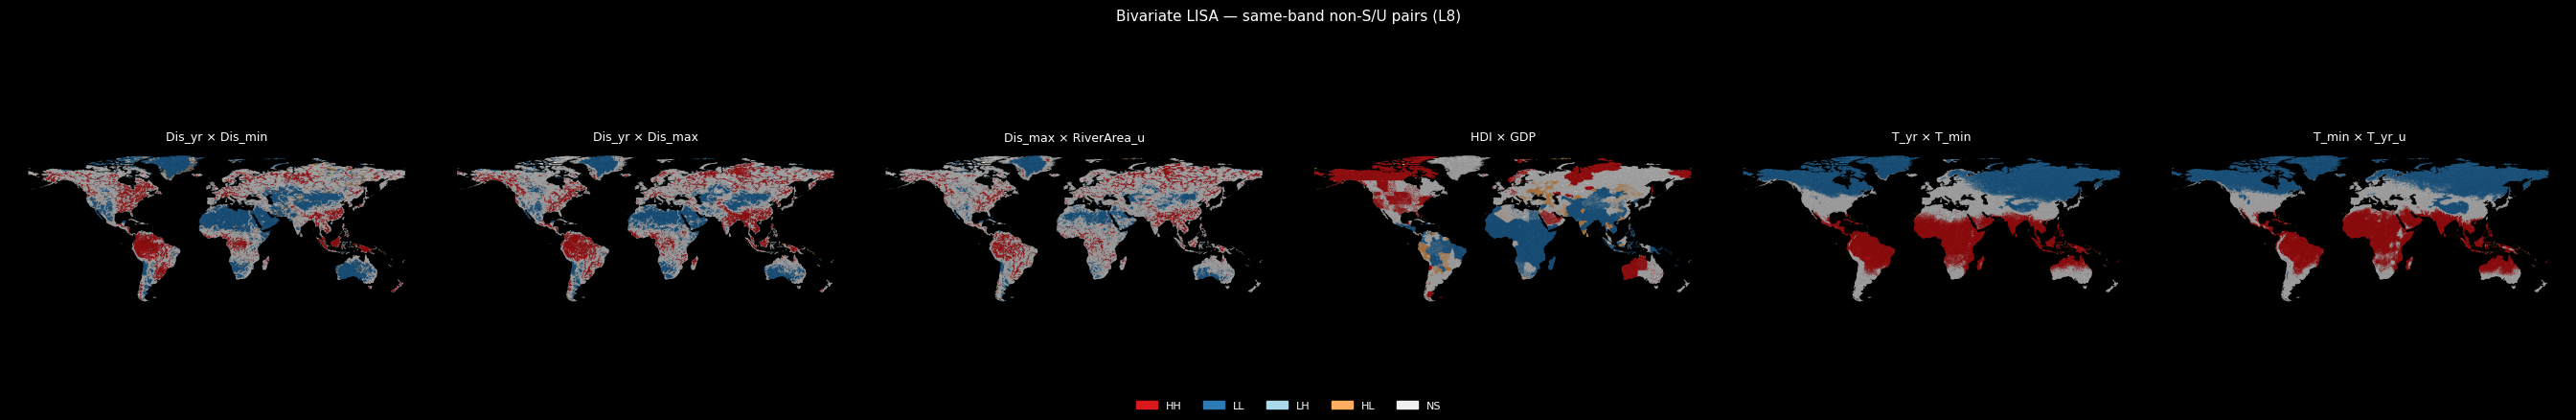

In [17]:
# Cell 17 — LISA maps: same-band non-S/U pairs (6 panels)
plot_group_maps(SB_PAIRS, 'Bivariate LISA — same-band non-S/U pairs (L8)', MAP_DIR / '15_bivariate_redundancy_sb.png')

## Save outputs

In [21]:
# Cell 19 — save bivariate_redundancy.parquet
all_df = pd.concat(dfs, ignore_index=True)
print(f'Total rows: {len(all_df):,}  ({len(ALL_PAIRS)} pairs × {len(gdf):,} basins)')
print(all_df.dtypes)

all_df.to_parquet(PARQ_OUT, index=False)
print(f'\nWritten: {PARQ_OUT}')

COUNTS_OUT = PARQ_OUT.parent / 'bivariate_redundancy_counts.csv'
counts = all_df.groupby(['group', 'pair_id', 'lisa_class']).size().unstack(fill_value=0)
counts.to_csv(COUNTS_OUT)
print(f'Written: {COUNTS_OUT}')
print(counts.to_string())


Written: /Users/karlg/Documents/repos/_cedop/output/edop/spatial/bivariate_redundancy.parquet
Written: /Users/karlg/Documents/repos/_cedop/output/edop/spatial/bivariate_redundancy_counts.csv
lisa_class            HH    HL    LH     LL      NS
group pair_id                                      
sb    dis_mx_ria   22893   726  6803  23278  136975
      dis_yr_mn    27652  3662  6641  53311   99409
      dis_yr_mx    29670   671  7296  38964  114074
      hdi_gdp      26134  8566     7  59514   96454
      tmp_smn_uyr  68042   413     0  49679   72541
      tmp_syr_smn  63459   375    14  52368   74459
su    ari_su       39541   528    10  36054  114542
      crp_su       29040   221   796  84596   76022
      hft_su       35022   591   478  62938   91646
      pre_su       33282   400    21  63277   93695
      tmp_su       68070   378     1  49716   72510


## Findings summary — Phase 3 CHAR: Within-band Bivariate Redundancy

All 11 pairs significant at p=0.001. Results at L8 (190,675 basins). Outputs: `output/edop/spatial/bivariate_redundancy.parquet` (2,097,425 rows), `bivariate_redundancy_counts.csv`.

---

### BVR.1 — S/U pairs: global I_BV reference grid

| Pair | I_BV | HH% | LL% | HL% | LH% | NS% |
|---|---|---|---|---|---|---|
| T_yr s×u | 0.989 | 35.7 | 26.1 | 0.2 | 0.0 | 38.0 |
| P_yr s×u | 0.963 | 17.5 | 33.2 | 0.2 | 0.0 | 49.1 |
| Ari s×u | 0.978 | 20.7 | 18.9 | 0.3 | 0.0 | 60.1 |
| HFT s×u | 0.826 | 18.4 | 33.0 | 0.3 | 0.3 | 48.1 |
| Crop s×u | 0.867 | 15.2 | 44.4 | 0.1 | 0.4 | 39.9 |

### BVR.2 — Same-band non-S/U pairs: global I_BV reference grid

| Pair | I_BV | HH% | LL% | HL% | LH% | NS% |
|---|---|---|---|---|---|---|
| Dis_yr × Dis_min | 0.525 | 14.5 | 28.0 | 1.9 | 3.5 | 52.1 |
| Dis_yr × Dis_max | 0.538 | 15.6 | 20.4 | 0.4 | 3.8 | 59.8 |
| Dis_max × RiverArea_u | 0.455 | 12.0 | 12.2 | 0.4 | 3.6 | 71.8 |
| HDI × GDP | 0.587 | 13.7 | 31.2 | 4.5 | 0.0 | 50.6 |
| T_yr × T_min | 0.969 | 33.3 | 27.5 | 0.2 | 0.0 | 39.1 |
| T_min × T_yr_u | 0.965 | 35.7 | 26.1 | 0.2 | 0.0 | 38.0 |

### BVR.3 — S/U divergence is globally rare; anthropogenic pairs show most

S/U divergence (HL+LH) ranges from 0.2% (T_yr, P_yr) to 0.6% (HFT). The local-vs-upstream duality identified in F3.x is real but spatially small — well under 1% of basins in each case. Climate s/u pairs are near-perfectly concordant: catchment-scale smoothing means a basin's temperature and precipitation closely mirrors its upstream catchment almost everywhere. HFT and Crop show the most s/u divergence (balanced HL/LH ~0.5% each) because anthropogenic land use does not respect catchment flow direction as cleanly as physical climate gradients do.

Aridity s×u has the highest NS fraction (60.1%) of all pairs. The aridity index (P/PET) spans humid-to-arid in transition zones where the upstream catchment crosses major moisture gradients, producing no coherent local autocorrelation signal.

### BVR.4 — Discharge pairs: attribute-space redundancy ≠ spatial concordance

I_BV for discharge pairs (0.455–0.538) falls *below* their univariate Moran's I (~0.563 at L8). High Pearson/Spearman r in attribute space does not imply high spatial concordance. The seasonal regime geography — which dis_min and dis_max capture independently from dis_yr — breaks the spatial lock.

All three discharge pairs show LH >> HL: basins with below-average annual discharge situated next to neighbors with above-average minimum or maximum discharge. For Dis_yr × Dis_min (LH=6,641 vs HL=3,662): cold-climate/snowmelt transition zones where small headwater basins have low annual flow but neighbor the great boreal perennial rivers. For Dis_yr × Dis_max (LH=7,296 vs HL=671): monsoon transition zones where flood-pulse peaks are concentrated in neighboring high-maximum systems. The asymmetric LH pattern identifies the seasonal-regime geography that annual discharge alone does not resolve.

### BVR.5 — Temperature triple is spatially interchangeable

T_yr, T_min (same band), and T_yr_upstream produce nearly identical LISA distributions (HH ~63–68k, LL ~49–52k, HL ~375–413, LH 0–14). The three temperature metrics form one spatial pattern. This is documented here as characterisation; no variables are removed from the signature (see design note below).

### BVR.6 — HDI×GDP: asymmetric development geography

HL=8,566 basins (4.5%), LH=7 basins (0.004%). High-HDI enclaves surrounded by low-GDP neighbors exist at significant scale; the reverse is essentially absent. The HL zone maps onto Eastern Europe and former Soviet states — high human development index (Soviet legacy: education, healthcare) in a neighborhood of below-average market GDP. LH≈0 reflects a one-directional causal chain: wherever GDP is high, HDI follows; the reverse is rare.

The HDI×GDP spatial pattern traces the temperate/tropical development divide and the modern North-South gradient. It reflects the accumulated outcome of environmental endowment, colonial history, and institutional development — not a direct environmental signal. For historical queries, Band D variables are future information relative to the period of interest and should be treated as opt-in context, not primary environmental characterisation.

### BVR.7 — Design note: global redundancy does not justify variable removal

The global bivariate concordance values documented here characterise the *typical* spatial relationship between paired variables. They do not license removing variables from L8 basin signatures. At the basin scale, variables that covary globally may carry distinct local information — particularly in the HL/LH divergence zones, which are often the ecologically and historically most interesting configurations. Phase 3 findings are documentation of co-variation structure for interpretive use, not a pruning pass.